# ICE and PG performance measure

## Dependencies

In [1]:
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

2025-11-24 07:03:08.356672: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 07:03:08.374613: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-24 07:03:08.374629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-24 07:03:08.375299: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-24 07:03:08.379403: I tensorflow/core/platform/cpu_feature_guar

As can be seen, it is not necessary to import `tensorflow` or `keras` unless required elsewhere in the process.

`ONNX_Predict` handles the process of loading into memory and the prediction interface for models and scalers

## Reading models and scalers

### Paths

The directories where the `onnx` models are stored, as well as the original `ICE` and `PG` models, are defined.

In [2]:
ICE_folder = os.path.join('CTTC_models', 'ONNX', 'ICE')
PG_folder = os.path.join('CTTC_models', 'ONNX', 'PG')
tf_model = 'model.h5'

### Loading ICE model in memory

To load the models into memory, an instance of the `Scaler_onnx` classes for the scalers and `LSTM_onnx` for the models must be created*

In [3]:
ICEscaler_in = Scaler_onnx('scaler_input.onnx', ICE_folder)
ICEscaler_out = Scaler_onnx('scaler_output.onnx', ICE_folder)
ICEscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', ICE_folder)
ICE = LSTM_onnx('ICE_onnx.onnx', ICE_folder, tf_model)

2025-11-18 16:16:41.083107744 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844221, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:41.088095804 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844224, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:41.093146881 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844222, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:41.098197497 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844223, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the numbe

**IMPORTANT**

Note that 3 scalers are loaded into memory instead of 2.

This is because onnx models can only transform in one direction. Requiring an inverse transformation for prediction meant generating `scaler_inverse_output.onnx` for each model

### Loading PG model in memory

In [4]:
PGscaler_in = Scaler_onnx('scaler_input.onnx', PG_folder)
PGscaler_out = Scaler_onnx('scaler_output.onnx', PG_folder)
PGscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', PG_folder)
PG = LSTM_onnx('PG_onnx.onnx', PG_folder, tf_model)

2025-11-18 16:16:51.895419712 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844274, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:51.900499151 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844278, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:51.901368694 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844282, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 16:16:51.902800839 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 844281, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the nu

Same as `ICE`

## Reading input vectors

### Path and config vars

Select the csv file `part_000100.csv`

In turn, the column names were taken from the model training data

In [8]:
csvPath = 'part_000100.csv'
input_cols = ['ICE_Speed_rpm', 'fuel_mg', 'T_amb_K', 'p_amb_bar', 
              'ICE_Speed_soll_rpm', 'EM2_Torque_Nm', 'ICE_Torque_Nm', 'Brake_perc']

#### Loading dataframe in memory

In [9]:
df = pd.read_csv(csvPath, names=input_cols, skiprows=1)
ICEinput = df.iloc[:,:4].copy()
PGinput = df.iloc[:,4:].copy()

#Adjusting speed value
PGinput.loc[PGinput['ICE_Speed_soll_rpm'] < 900] = 0

## Preprocess

### Model Reset

In [10]:
ICE.reset_states()

### Input vector

We will work with the first row of the selected file

In [11]:
x = ICEinput.iloc[:1].copy()
x = x.to_numpy()
x = x.astype('float32')

#### Scaling the input vector

In [12]:
x_scaled = ICEscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

**IMPORTANT:**

We work directly with `numpy` for vector casting and/or reshaping tasks, instead of using `tensorflow`

### Preparing initial auxiliar data

The default data defined in the `transition_function_model` class defined in the script with the same name is taken as an example:

- Torque  --> 0 
- NO_ini  --> 0
- NO2_ini --> 0
- CO_ini  --> 0
- CO2_ini --> 0

In [13]:
Torque = 0
NO_ini = 0
NO2_ini = 0
CO_ini = 0
CO2_ini = 0
y_ini = np.array([[Torque, NO_ini, NO2_ini, CO_ini, CO2_ini]], dtype='float32')
y_scaled_ini = ICEscaler_out.transform(y_ini)[0].reshape((1,1,5))

## Prediction

### ICE model prediction behaviour

In [14]:
y_predict_scaled_list = []

y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled#### - 1st prediction call

In [15]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.79309154, -0.99261713, -0.9964769 , -0.99629915,
          -0.9952043 ]]], dtype=float32)]

In [16]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.36389303, -0.99757624, -1.0069705 , -1.0029442 ,
          -0.99704516]]], dtype=float32)]

#### - 2nd prediction call

In [17]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14948566, -0.9296564 , -0.9802153 , -0.94951165,
          -0.9990152 ]]], dtype=float32)]

#### - 3rd prediction call

In [18]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14641733, -0.6010861 , -0.9596789 , -0.9276561 ,
          -0.99618065]]], dtype=float32)]

#### - 4th prediction call

In [19]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14785172, -0.51661503, -0.99532473, -0.94011337,
          -0.99781585]]], dtype=float32)]

#### - 5th prediction call

In [20]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.1537324 , -0.59250104, -0.99925673, -0.9374767 ,
          -0.99355257]]], dtype=float32)]

### Plot of scaled results

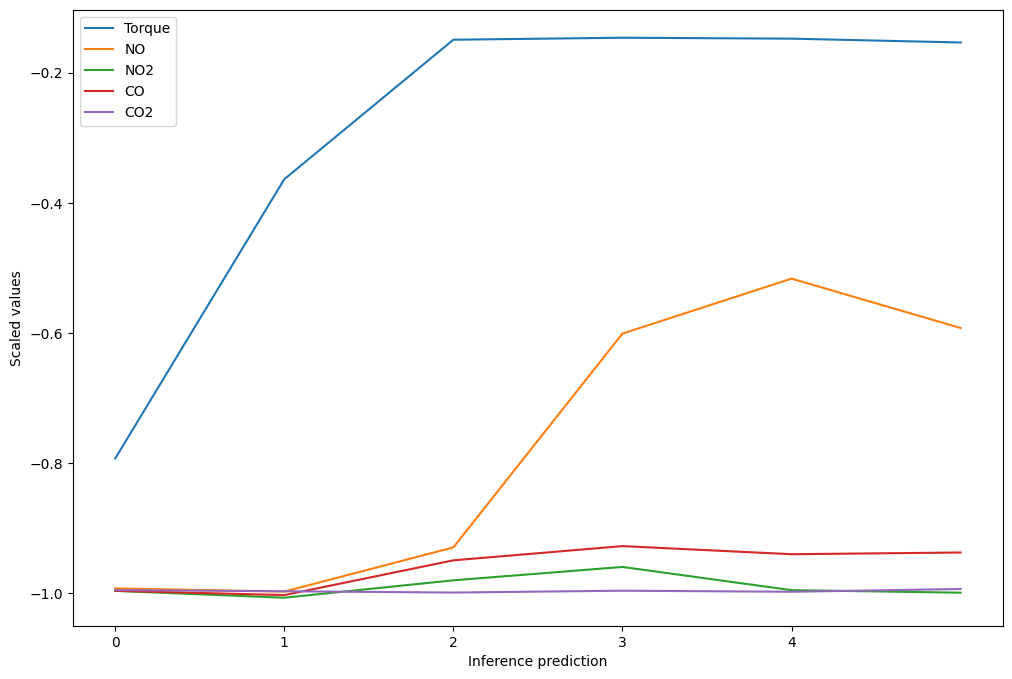

In [21]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Torque', 'NO', 'NO2', 'CO', 'CO2']

_, ax = plt.subplots(figsize=(12,8))
for var in range(plot_vars):
    ax.plot(plot_data[:,var], label=labels[var])

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction')
ax.legend()

plt.show()

2025-11-18 17:33:59.665376: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 17:33:59.686817: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-18 17:33:59.686833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-18 17:33:59.687508: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-18 17:33:59.691342: I tensorflow/core/platform/cpu_feature_guar

⚙️ Configurando entorno ONNX...
   📍 ICE: CTTC_models/ONNX/ICE
   📍 PG:  CTTC_models/ONNX/PG


2025-11-18 17:34:02.087012043 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848550, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:02.087024155 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848552, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:02.087045906 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848551, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:02.087042800 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848553, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the numbe


--- Iniciando Experimento de Predicción Recurrente (ICE) ---

🔄 Modelos reseteados a estado inicial.
Call 1: Torque Predicho = -26.2617 Nm
Call 2: Torque Predicho = 100.6283 Nm
Call 3: Torque Predicho = 178.3530 Nm
Call 4: Torque Predicho = 180.7190 Nm
Call 5: Torque Predicho = 182.5785 Nm

Generando gráfico de evolución...


2025-11-18 17:34:03.870821758 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848617, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:03.870913929 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848622, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:03.873466843 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848643, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:34:03.873475168 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 848644, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the numbe

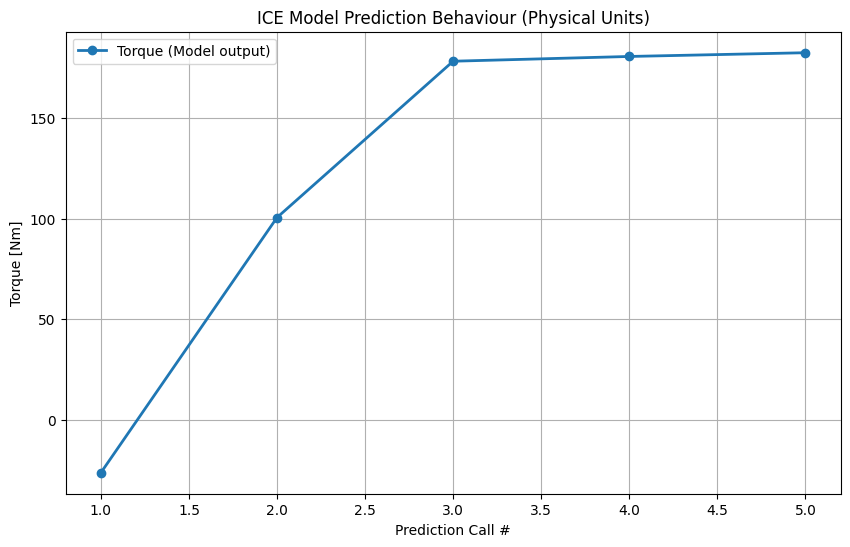

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# We import the configuration function from your trans.py file
from trans import setup_transition_function_model

# 1. Path configuration (Adjust this to your actual folders)
ruta_ICE_model = os.path.join("CTTC_models", "ONNX", "ICE")
ruta_outlook = os.path.join("CTTC_models", "ONNX", "PG")

# 2. Initialize the environment
# This loads the ONNX models and scalers
t_function = setup_transition_function_model(ruta_ICE_model, ruta_outlook)

# 3. Define a CONSTANT input for the experiment
# In the image you used constant 'x_scaled'. Here we define constant physical values.
# Adjust these values to something representative for your engine.
inputs_fisicos = {
    'Speed_rpm': 2000.0,
    'm_fuel_mg': 35.0,
    'T_amb_K': 298.0,
    'p_amb_bar': 1.013
}

print("\n--- Starting Recurrent Prediction Experiment (ICE) ---\n")

# 4. Reset states (Important to start from scratch, same as in the image)
t_function.reset_models()

y_predict_torque_list = []
n_pasos = 5

# 5. Prediction loop (5 consecutive calls)
for i in range(n_pasos):
    # We call predict_ice. 
    # Internally: Scale inputs -> Infer (using previous state) -> Update state -> Descale output
    Torque_Nm, NO_out, NO2_out, CO_out, CO2_out = t_function.predict_ice(
        Speed_rpm=inputs_fisicos['Speed_rpm'],
        m_fuel_mg=inputs_fisicos['m_fuel_mg'],
        T_amb_K=inputs_fisicos['T_amb_K'],
        p_amb_bar=inputs_fisicos['p_amb_bar']
    )
    
    # We save the Torque (equivalent to the first value you showed in the image array)
    y_predict_torque_list.append(Torque_Nm)
    
    print(f"Call {i+1}: Torque Predicho = {Torque_Nm:.4f} Nm")
    # If you want to see how emissions change, you can print them too
    # print(f"        NOx: {NO_out:.2f}, CO2: {CO2_out:.2f}")

# 6. Plot results
print("\nGenerating evolution graph...")

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_pasos + 1), y_predict_torque_list, 'o-', linewidth=2, label='Torque (Model output)')
plt.title('ICE Model Prediction Behaviour (Physical Units)')
plt.xlabel('Prediction Call #')
plt.ylabel('Torque [Nm]')
plt.grid(True)
plt.legend()

# Show graph
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We import the ONNX libraries
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx

# ==============================================================================
# 1. DEFINITION OF THE NEW METHOD (CLASS AND SETUP)
#    (Includes flatten and [0] fixes so it doesn't fail)
# ==============================================================================

def setup_transition_function_model(ruta_ICE, ruta_PG, SOC_ini=0.7):
    tf_model_ref = 'model.h5' 
    ice_model = LSTM_onnx('ICE_onnx.onnx', ruta_ICE, tf_model_ref)
    ice_scalers = {
        'in': Scaler_onnx('scaler_input.onnx', ruta_ICE),
        'out': Scaler_onnx('scaler_output.onnx', ruta_ICE),
        'inv_out': Scaler_onnx('scaler_inverse_output.onnx', ruta_ICE)
    }
    pg_model = LSTM_onnx('PG_onnx.onnx', ruta_PG, tf_model_ref)
    pg_scalers = {
        'in': Scaler_onnx('scaler_input.onnx', ruta_PG),
        'out': Scaler_onnx('scaler_output.onnx', ruta_PG),
        'inv_out': Scaler_onnx('scaler_inverse_output.onnx', ruta_PG)
    }
    return transition_function_model(ice_model, pg_model, ice_scalers, pg_scalers, SOC_ini=SOC_ini)

class transition_function_model:
    def __init__(self, ICE_model, PG_model, ICE_scalers, PG_scalers,
                 Torque=0, NO_ini=0, NO2_ini=0, CO_ini=0, CO2_ini=0,
                 velocity_ini=0, SOC_ini=0.7, show_progress=False):
        self.ICE_model = ICE_model
        self.PG_model = PG_model
        self.ICE_scalers = ICE_scalers
        self.PG_scalers = PG_scalers

        self.init_vals_ICE = np.array([[Torque, NO_ini, NO2_ini, CO_ini, CO2_ini]], dtype='float32')
        self.init_vals_PG = np.array([[velocity_ini, SOC_ini]], dtype='float32')
        
        # State initialization
        self.initial_ice_aux = self.ICE_scalers['out'].transform(self.init_vals_ICE)[0].reshape((1, 1, 5))
        self.initial_pg_aux = self.PG_scalers['out'].transform(self.init_vals_PG)[0].reshape((1, 1, 2))

        self.ice_aux = self.initial_ice_aux.copy()
        self.pg_aux = self.initial_pg_aux.copy()
        self.results = []

    def reset_models(self):
        if hasattr(self.ICE_model, 'reset_states'): self.ICE_model.reset_states()
        if hasattr(self.PG_model, 'reset_states'): self.PG_model.reset_states()
        self.ice_aux = self.initial_ice_aux.copy()
        self.pg_aux = self.initial_pg_aux.copy()
        self.results = []

    def predict_ice(self, Speed_rpm, m_fuel_mg, T_amb_K, p_amb_bar):
        # 1. Pack
        x = np.array([[Speed_rpm, m_fuel_mg, T_amb_K, p_amb_bar]], dtype='float32')
        # 2. Scale
        x_scaled = self.ICE_scalers['in'].transform(x)
        x_scaled = np.reshape(x_scaled, (1, 1, 4))
        # 3. Predict
        y_predict_scaled = self.ICE_model([x_scaled, self.ice_aux])
        
        curr_output_scaled = y_predict_scaled[0] # Fix list
        curr_output_scaled = curr_output_scaled.reshape((1, 1, 5)) # Fix rank
        
        self.ice_aux = curr_output_scaled.astype('float32')
        
        # 4. Descale
        y_phys = self.ICE_scalers['inv_out'].transform(curr_output_scaled.reshape(1, 5))
        vals = np.array(y_phys).flatten() # Fix unpack
        return vals # We return an array of 5 physical values

# ==============================================================================
# 2. COMMON DATA PREPARATION
# ==============================================================================
print("--- Generating input data ---")

# Paths
ICE_folder = os.path.join('CTTC_models', 'ONNX', 'ICE')
PG_folder = os.path.join('CTTC_models', 'ONNX', 'PG')
tf_model = 'model.h5'

# Dummy Data (Simulating the CSV row)
input_data = {
    'ICE_Speed_rpm': 2000.0, 
    'fuel_mg': 35.0, 
    'T_amb_K': 298.0, 
    'p_amb_bar': 1.013
}
# We convert to Numpy so it's the exact same source for both
x_source = np.array([[input_data['ICE_Speed_rpm'], input_data['fuel_mg'], 
                      input_data['T_amb_K'], input_data['p_amb_bar']]], dtype='float32')


# ==============================================================================
# 3. METHOD A EXECUTION: "NEW CODE" (CLASS)
# ==============================================================================
print("\n🔵 Executing METHOD A (New Class)...")

# Setup
model_A = setup_transition_function_model(ICE_folder, PG_folder)
model_A.reset_models()

results_A = []

for i in range(5):
    # The class does everything: scale -> predict -> descale

--- Generando datos de entrada ---

🔵 Ejecutando MËTODO A (Clase Nueva)...


2025-11-18 17:45:41.472124981 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 849356, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:45:41.477205302 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 849359, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:45:41.477860797 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 849364, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-11-18 17:45:41.478382174 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 849360, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the num


🟠 Ejecutando MÉTODO B (Manual)...


📊 --- TABLA COMPARATIVA (Torque output) ---
Iter  | Método A (Nm)   | Método B (Nm)   | Diferencia     
------------------------------------------------------------
1     | -26.26166       | -26.26166       | 0.00000000     
2     | 100.62829       | 100.62829       | 0.00000000     
3     | 178.35304       | 178.35304       | 0.00000000     
4     | 180.71898       | 180.71898       | 0.00000000     
5     | 182.57851       | 182.57851       | 0.00000000     
------------------------------------------------------------

✅ ÉXITO: Ambos métodos dan EXACTAMENTE el mismo resultado.

Diferencia acumulada total (todas las variables): 0.0000000000


## ICE preformance time

In [22]:
%%timeit
ICE([x_scaled, y_scaled_ini])

30.1 μs ± 77.6 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [23]:
y_pred_list = []

for pred in range(preds):
    y_pred = ICEscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [24]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Torque,NO,NO2,CO,CO2
0,-30.663244,0.001071,0.000008,0.000536,0.002289
1,91.710686,0.000352,-0.000015,-0.000426,0.001410
2,152.842941,0.010206,0.000043,0.007306,0.000470
3,153.717789,0.057880,0.000087,0.010468,0.001823
4,153.308807,0.070137,0.000010,0.008666,0.001042
5,151.632095,0.059126,0.000002,0.009047,0.003077


#### Basic statistics

In [25]:
y_pred.describe().loc[['mean', 'std']]

,Torque,NO,NO2,CO,CO2
mean,112.091515,0.033129,0.000022,0.005933,0.001685
std,74.094597,0.032513,0.000037,0.004673,0.000926


**IMPORTANT:**

It can be observed how the first torque prediction produces a negative result --> `-30.66 Nm`

### Plot results

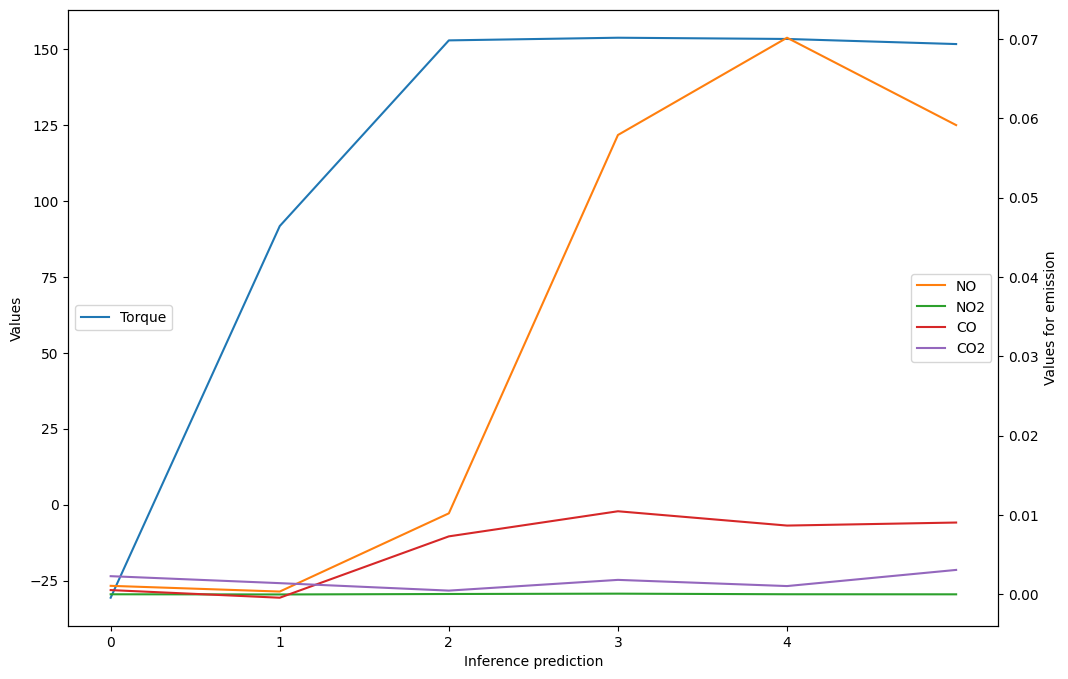

In [26]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for emission')
ax2.legend(loc='center right')

plt.show()

## Repeat process for PG

### Model reset

In [27]:
PG.reset_states()

### Prepare input vector

As with the ICE model, the first row of the selected file is selected

In [28]:
x = PGinput.iloc[:1].copy()

#### Removing NaN value

In [29]:
x.iloc[:,2] = y_pred['Torque'].iloc[-1]
x = x.to_numpy()
x = x.astype('float32')

#### Scalling the input vector 

In [30]:
x_scaled = PGscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

#### Preparing initial auxiliar vector

Again, the default values defined in the files `main.ipynb` and `transition_function_model.py` are taken

In [31]:
SOC_ini = 0.7
velocity_ini = 0

y_ini = np.array([[velocity_ini, SOC_ini]], dtype='float32')
y_scaled_ini = PGscaler_out.transform(y_ini)[0].reshape((1,1,2))

### PG model prediction behaviour

A behavior similar to the ICE model has been evidenced but with much smaller variations than those observed for ICE

In [32]:
y_predict_scaled_list = []

#### - 1st prediction call

In [33]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19866475,  0.40247998]]], dtype=float32)]

#### - 2nd prediction call

In [34]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.20070802,  0.40876177]]], dtype=float32)]

#### - 3rd prediction call

In [35]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.18931873,  0.4032998 ]]], dtype=float32)]

#### - 4th prediction call

In [36]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19693069,  0.40699327]]], dtype=float32)]

#### - 5th prediction call

In [37]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19303307,  0.40722346]]], dtype=float32)]

Please note how the values of the input vector set are **NOT modified** between calls. That is, for the same set of input vectors, different prediction values are obtained.

### Plotting scaled results

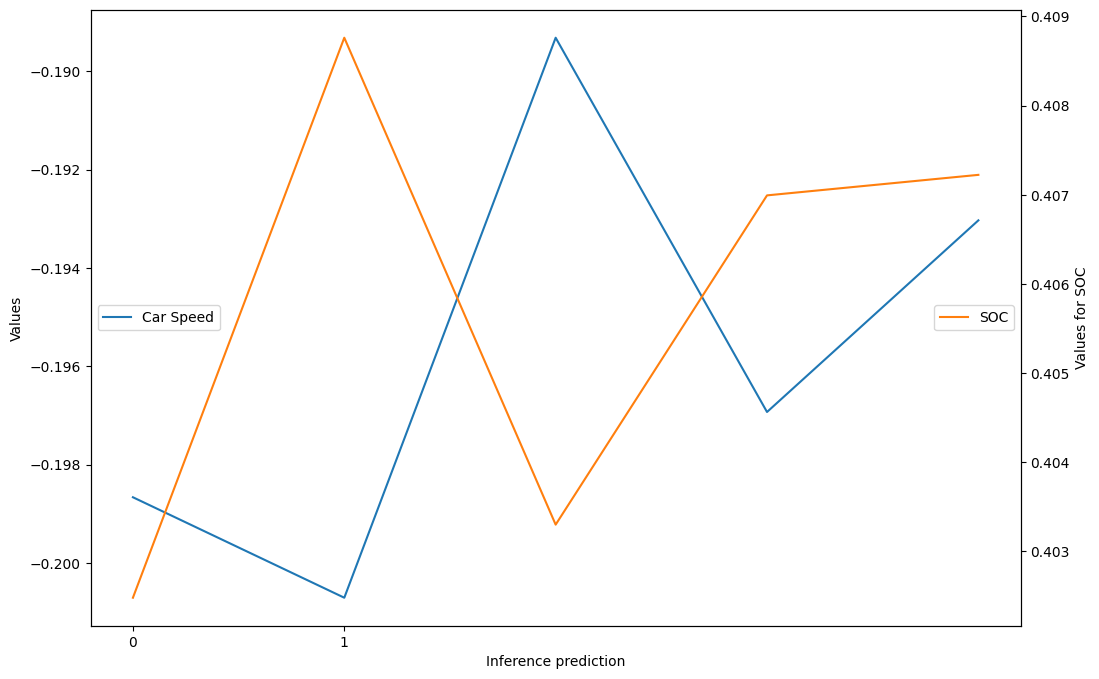

In [38]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Car Speed', 'SOC']

_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()

## PG preformance time

In [39]:
%%timeit
PG([x_scaled, y_scaled_ini])

85.6 μs ± 7.21 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [40]:
y_pred_list = []

for pred in range(preds):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [41]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Car Speed,SOC
0,0.932804,0.701027
1,0.593681,0.704167
2,2.483977,0.701437
3,1.220609,0.703283
4,1.867503,0.703398


#### Basic statistics

In [42]:
y_pred.describe().loc[['mean', 'std']]

,Car Speed,SOC
mean,1.419715,0.702662
std,0.757005,0.001357


**Important:**

Observe the high standard deviation value of the predicted speed for the same pair of input vectors

### Plot results

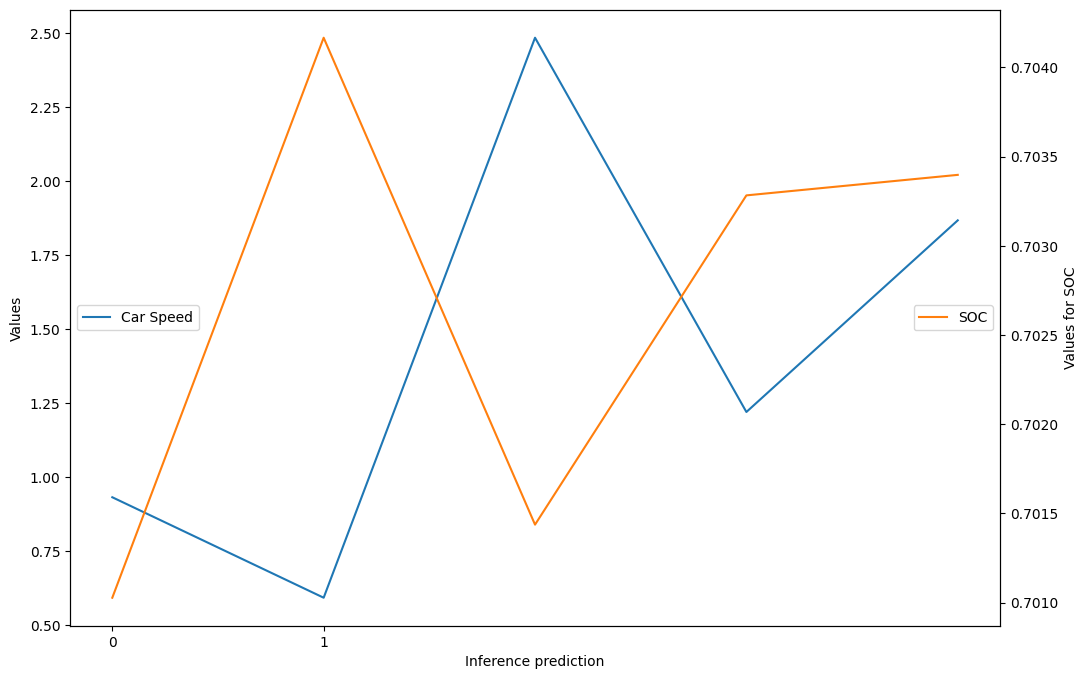

In [43]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()